In [14]:
import os
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# ================================
# STEP 0: LOAD DATA
# ================================
df = pd.read_csv("data/cleaned/final_cleaned_dataset.csv")

# ================================
# STEP 1: TARGET & FEATURES
# ================================
target_candidates = [col for col in df.columns if "yield" in col.lower()]
if not target_candidates:
    raise ValueError("No column with 'yield' found in dataset!")
target = target_candidates[0]

exclude_cols = ["Country", "Year"]
features = df.columns.difference(exclude_cols + [target])
X = df[features]
y = df[target]

# ================================
# STEP 2: SPLIT DATA
# ================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, shuffle=False
)

# ================================
# STEP 3: SCALE FEATURES
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler_xgb.pkl")

# ================================
# STEP 4: CONVERT TO DMatrix
# ================================
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dval   = xgb.DMatrix(X_val_scaled, label=y_val)
dtest  = xgb.DMatrix(X_test_scaled, label=y_test)

# ================================
# STEP 5: TRAIN MODEL WITH EARLY STOPPING
# ================================
params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42
}

evals = [(dtrain, "train"), (dval, "val")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=True
)

# Save trained model
bst.save_model("models/xgb_model_earlystop.json")

# ================================
# STEP 6: PREDICTION & EVALUATION
# ================================
y_pred = bst.predict(dtest)

rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n=== MODEL PERFORMANCE ===")
print(f"RMSE  : {rmse:.2f}")
print(f"MAE   : {mae:.2f}")
print(f"R²    : {r2:.4f}")
print(f"MAPE  : {mape:.2f} %")

[0]	train-rmse:2124.98065	val-rmse:1483.64324
[1]	train-rmse:2027.09080	val-rmse:1411.86665
[2]	train-rmse:1934.02581	val-rmse:1345.69793
[3]	train-rmse:1844.69059	val-rmse:1284.98675
[4]	train-rmse:1760.73752	val-rmse:1227.02869
[5]	train-rmse:1681.04293	val-rmse:1171.64995
[6]	train-rmse:1605.26981	val-rmse:1122.61799
[7]	train-rmse:1533.37167	val-rmse:1073.81383
[8]	train-rmse:1465.53113	val-rmse:1026.38450
[9]	train-rmse:1400.67376	val-rmse:983.12944
[10]	train-rmse:1339.84049	val-rmse:942.91061
[11]	train-rmse:1282.17579	val-rmse:901.47031
[12]	train-rmse:1227.25088	val-rmse:866.35318
[13]	train-rmse:1174.10093	val-rmse:830.33358
[14]	train-rmse:1125.11219	val-rmse:800.01336
[15]	train-rmse:1078.08011	val-rmse:772.86703
[16]	train-rmse:1033.38702	val-rmse:746.35639
[17]	train-rmse:991.12691	val-rmse:723.98963
[18]	train-rmse:951.55036	val-rmse:697.94426
[19]	train-rmse:914.30488	val-rmse:672.70570
[20]	train-rmse:878.88982	val-rmse:651.84475
[21]	train-rmse:845.00845	val-rmse:630.

[0]	train-rmse:2124.98065	val-rmse:1483.64324
[1]	train-rmse:2027.09080	val-rmse:1411.86665
[2]	train-rmse:1934.02581	val-rmse:1345.69793
[3]	train-rmse:1844.69059	val-rmse:1284.98675
[4]	train-rmse:1760.73752	val-rmse:1227.02869
[5]	train-rmse:1681.04293	val-rmse:1171.64995
[6]	train-rmse:1605.26981	val-rmse:1122.61799
[7]	train-rmse:1533.37167	val-rmse:1073.81383
[8]	train-rmse:1465.53113	val-rmse:1026.38450
[9]	train-rmse:1400.67376	val-rmse:983.12944
[10]	train-rmse:1339.84049	val-rmse:942.91061
[11]	train-rmse:1282.17579	val-rmse:901.47031
[12]	train-rmse:1227.25088	val-rmse:866.35318
[13]	train-rmse:1174.10093	val-rmse:830.33358
[14]	train-rmse:1125.11219	val-rmse:800.01336
[15]	train-rmse:1078.08011	val-rmse:772.86703
[16]	train-rmse:1033.38702	val-rmse:746.35639
[17]	train-rmse:991.12691	val-rmse:723.98963
[18]	train-rmse:951.55036	val-rmse:697.94426
[19]	train-rmse:914.30488	val-rmse:672.70570
[20]	train-rmse:878.88982	val-rmse:651.84475
[21]	train-rmse:845.00845	val-rmse:630.

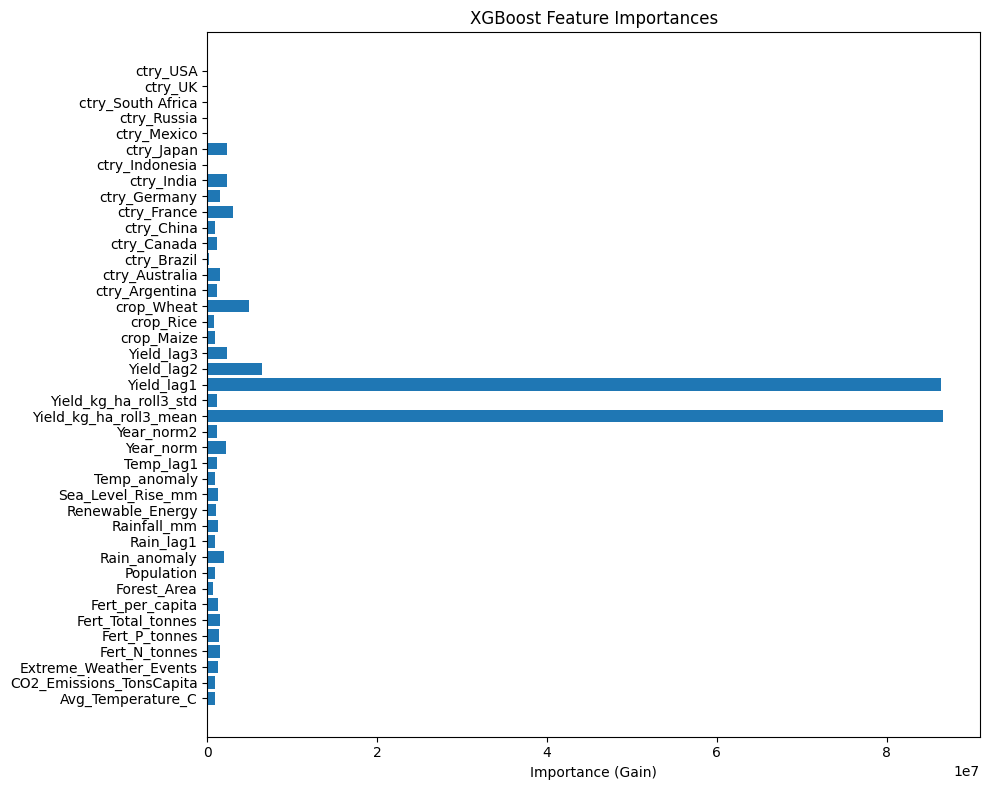


Pipeline saved as 'models/xgb_pipeline.pkl'


In [19]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ================================
# STEP 0: LOAD DATA
# ================================
df = pd.read_csv("data/cleaned/final_cleaned_dataset.csv")

# ================================
# STEP 1: TARGET & FEATURES
# ================================
target_candidates = [col for col in df.columns if "yield" in col.lower()]
if not target_candidates:
    raise ValueError("No column with 'yield' found in dataset!")
target = target_candidates[0]

exclude_cols = ["Country", "Year"]
features = list(df.columns.difference(exclude_cols + [target]))  # convert to list
X = df[features]
y = df[target]

# ================================
# STEP 2: SPLIT DATA
# ================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, shuffle=False
)

# ================================
# STEP 3: SCALE FEATURES
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler_xgb.pkl")

# ================================
# STEP 4: CONVERT TO DMATRIX
# ================================
dtrain = xgb.DMatrix(X_train_scaled, label=y_train, feature_names=features)
dval   = xgb.DMatrix(X_val_scaled, label=y_val, feature_names=features)
dtest  = xgb.DMatrix(X_test_scaled, label=y_test, feature_names=features)

# ================================
# STEP 5: TRAIN MODEL WITH EARLY STOPPING
# ================================
params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42
}

evals = [(dtrain, "train"), (dval, "val")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=True
)

bst.save_model("models/xgb_model_earlystop.json")

# ================================
# STEP 6: PREDICTION & EVALUATION
# ================================
y_pred = bst.predict(dtest)

rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n=== MODEL PERFORMANCE ===")
print(f"RMSE  : {rmse:.2f}")
print(f"MAE   : {mae:.2f}")
print(f"R²    : {r2:.4f}")
print(f"MAPE  : {mape:.2f} %")

# ================================
# STEP 7: FEATURE IMPORTANCE
# ================================
importances = bst.get_score(importance_type="gain")
feat_importances = [importances.get(f, 0) for f in features]

plt.figure(figsize=(10, 8))
plt.barh(features, feat_importances)
plt.xlabel("Importance (Gain)")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# ================================
# STEP 8: PER-CROP PERFORMANCE
# ================================
if "Crop" in df.columns:
    crops = df.loc[X_test.index, "Crop"].unique()
    print("\n=== PER-CROP PERFORMANCE ===")
    for crop in crops:
        idx = df.loc[X_test.index, "Crop"] == crop
        y_true_crop = y_test[idx]
        y_pred_crop = y_pred[idx]
        if len(y_true_crop) > 0:
            rmse_crop = np.sqrt(np.mean((y_true_crop - y_pred_crop) ** 2))
            r2_crop = r2_score(y_true_crop, y_pred_crop)
            print(f"{crop:10}: R² = {r2_crop:.4f}, RMSE = {rmse_crop:.2f}, n = {len(y_true_crop)}")

# ================================
# STEP 9: SAVE PIPELINE (WORKING)
# ================================
# Wrap booster in XGBRegressor for sklearn pipeline
xgb_model = XGBRegressor()
xgb_model._Booster = bst
xgb_model._le = None

pipeline = Pipeline([
    ("scaler", scaler),
    ("xgb", xgb_model)
])
joblib.dump(pipeline, "models/xgb_pipeline.pkl")
print("\nPipeline saved as 'models/xgb_pipeline.pkl'")


--- TRAIN METRICS ---
RMSE  : 255.7467
MAE   : 166.1282
Median AE : 98.8437
R²    : 0.9868
Explained Variance : 0.9868
Max Error : 2299.3306
MAPE (%)  : 3.86
sMAPE (%) : 3.76
MSLE      : 0.004011476210949004


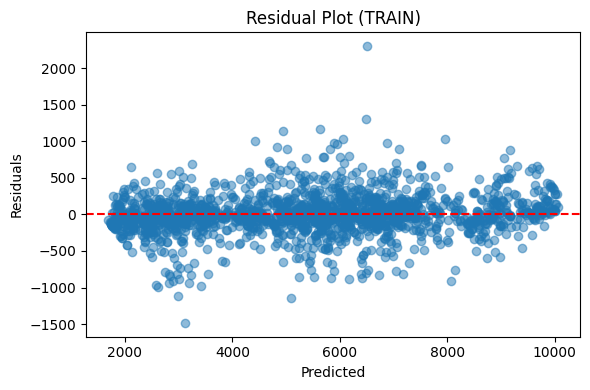


--- VALIDATION METRICS ---
RMSE  : 454.5768
MAE   : 275.3273
Median AE : 141.2339
R²    : 0.8921
Explained Variance : 0.8933
Max Error : 2261.7204
MAPE (%)  : 6.59
sMAPE (%) : 6.53
MSLE      : 0.012283297407021707


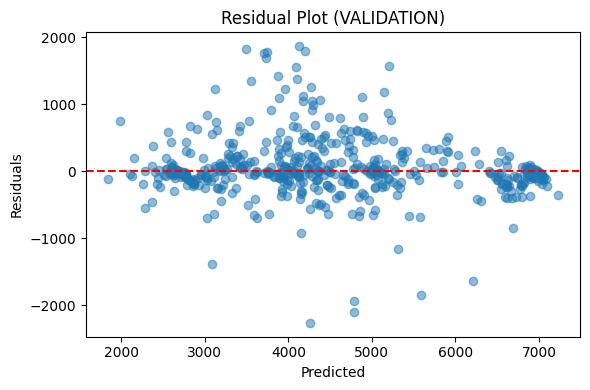


--- TEST METRICS ---
RMSE  : 540.9168
MAE   : 335.6011
Median AE : 191.7198
R²    : 0.9588
Explained Variance : 0.9595
Max Error : 4387.8716
MAPE (%)  : 7.13
sMAPE (%) : 7.01
MSLE      : 0.012024029750935954


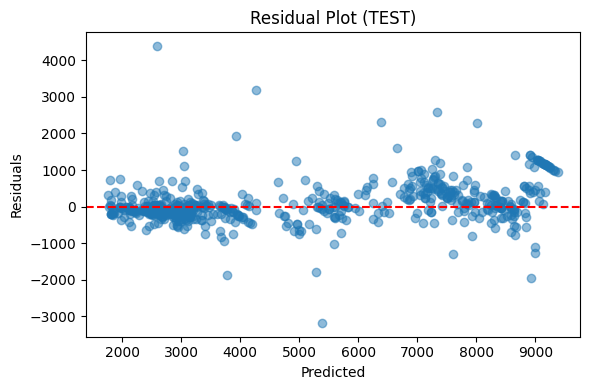

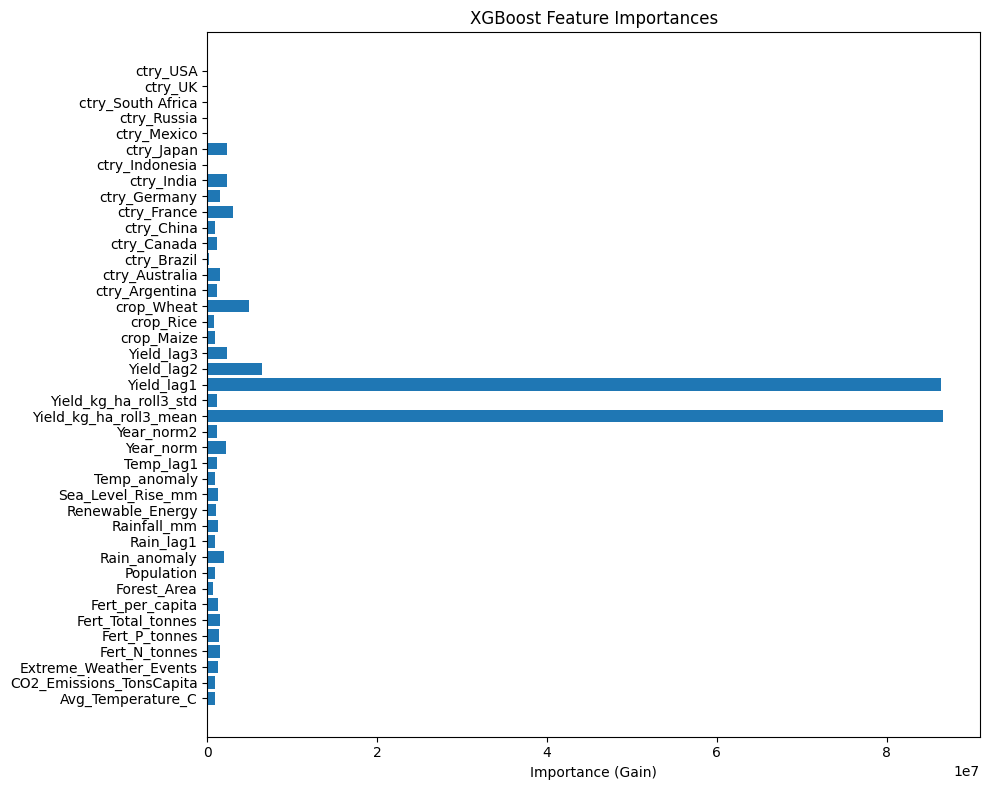

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error, r2_score, explained_variance_score, 
    median_absolute_error, max_error, mean_squared_log_error
)
import xgboost as xgb

# ================================
# ASSUME YOUR DATA & MODEL ARE LOADED
# ================================
# df : your full dataframe
# bst : trained xgb.Booster
# X_train_scaled, X_val_scaled, X_test_scaled
# y_train, y_val, y_test
# features : list of feature names

# ================================
# STEP 1: PREDICTIONS
# ================================
dtrain = xgb.DMatrix(X_train_scaled, label=y_train, feature_names=features)
dval   = xgb.DMatrix(X_val_scaled, label=y_val, feature_names=features)
dtest  = xgb.DMatrix(X_test_scaled, label=y_test, feature_names=features)

y_pred_train = bst.predict(dtrain)
y_pred_val   = bst.predict(dval)
y_pred_test  = bst.predict(dtest)

# ================================
# STEP 2: METRICS FUNCTION
# ================================
def regression_metrics(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae  = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    ev   = explained_variance_score(y_true, y_pred)
    maxerr = max_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    msle = mean_squared_log_error(y_true, y_pred) if (y_true >= 0).all() and (y_pred >= 0).all() else np.nan

    print(f"\n--- {name} METRICS ---")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"Median AE : {medae:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"Explained Variance : {ev:.4f}")
    print(f"Max Error : {maxerr:.4f}")
    print(f"MAPE (%)  : {mape:.2f}")
    print(f"sMAPE (%) : {smape:.2f}")
    print(f"MSLE      : {msle}")

    # Residual plot
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({name})")
    plt.tight_layout()
    plt.show()

# ================================
# STEP 3: EVALUATE TRAIN, VAL, TEST
# ================================
regression_metrics(y_train, y_pred_train, "TRAIN")
regression_metrics(y_val, y_pred_val, "VALIDATION")
regression_metrics(y_test, y_pred_test, "TEST")

# ================================
# STEP 4: FEATURE IMPORTANCE
# ================================
importances = bst.get_score(importance_type="gain")
feat_importances = [importances.get(f, 0) for f in features]

plt.figure(figsize=(10, 8))
plt.barh(features, feat_importances)
plt.xlabel("Importance (Gain)")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# ================================
# STEP 5: PER-CROP PERFORMANCE (IF EXISTS)² ---- accuracy ; matrice confusion 
# ================================
if "Crop" in df.columns:
    crops = df.loc[X_test.index, "Crop"].unique()
    print("\n=== PER-CROP PERFORMANCE ===")
    for crop in crops:
        idx = df.loc[X_test.index, "Crop"] == crop
        y_true_crop = y_test[idx]
        y_pred_crop = y_pred_test[idx]
        if len(y_true_crop) > 0:
            rmse_crop = np.sqrt(np.mean((y_true_crop - y_pred_crop) ** 2))
            r2_crop = r2_score(y_true_crop, y_pred_crop)
            print(f"{crop:10}: R² = {r2_crop:.4f}, RMSE = {rmse_crop:.2f}, n = {len(y_true_crop)}")